In [105]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import PIL
import PIL.Image
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.filters import gaussian

E_shift = 2
excluded_elements = {"al", "ag", "s", "si", "na"}
padding_size = 196  
grid_size = (5, 5)
box_size = (16, 16)
offset = (9, 9)
spacing = (6, 6)
image_path = "data/plots/pads_palette_photo.png"
object_path = "data/objects/Blank_PcbCu/GEM_Cr_PBS1_Blank_PcbCu_ArCO2_75_25_Gain_35_Thr_35_HV_3640_Xray_50kV_04mA_part_001_GainCorr.pcap.dat.npz"

def load_npz_file(fn):
    filename, file_extension = os.path.splitext(fn)
    if file_extension == '.npz' or os.path.exists(filename + '.npz'):
        npz_file = np.load(fn,allow_pickle=True)
        E_xy_histo = npz_file['E_xy']
        return E_xy_histo


def generate_bounding_boxes(grid_size, box_size, offset, spacing, pads):
    positions = {}
    rows, cols = grid_size
    box_h, box_w = box_size
    x_offset, y_offset = offset
    x_spacing, y_spacing = spacing

    count = 1
    for i in range(rows):
        for j in range(cols):
            x1 = x_offset + i * (box_h + x_spacing)
            x2 = x1 + box_h
            y1 = y_offset + j * (box_w + y_spacing)
            y2 = y1 + box_w
            positions[pads[i*cols + j]] = (x1, x2, y1, y2)
            count += 1
    
    return positions

def filtered_element_name(pad_name, excluded_elements):
    return "_".join([name for name in pad_name.split("_") if name not in excluded_elements])

def apply_smoothing_and_padding(pads_e_xy, padding_size):
    smoothed_pads_e_xy = gaussian(pads_e_xy, sigma=0.6)
    smoothed_pads_e_xy = np.apply_along_axis(
        gaussian, axis=2, arr=smoothed_pads_e_xy, sigma=64, preserve_range=True
    )
    smoothed_pads_e_xy[:, :, :padding_size] = 0
    smoothed_pads_e_xy[:, :, -padding_size:] = 0

    return smoothed_pads_e_xy 

def select_pads(pads_e_xy, pad_positions, E_shift):
    selected_pads = {
        name: pads_e_xy[x1:x2, y1:y2].astype(float) / (1 << E_shift)
        for name, (x1, x2, y1, y2) in pad_positions.items()
    }

    mask = np.ones_like(pads_e_xy, dtype=bool)
    for name, (x1, x2, y1, y2) in pad_positions.items():
        mask[x1-4:x2+4, y1-4:y2+4] = False if name != "wood" else True

    wood_pad = (pads_e_xy[4:-4, 4:-4][mask[4:-4, 4:-4]].astype(float) / (1 << E_shift)).reshape(-1, pads_e_xy.shape[-1])
    square_side = int(np.sqrt(wood_pad.shape[0]))
    wood_pad = wood_pad[:square_side**2, :].reshape(square_side, square_side, pads_e_xy.shape[-1])
    selected_pads["wood"] = wood_pad
    print(selected_pads["wood"].shape)

    return selected_pads 

def filter_pads(selected_pads, excluded_elements):
    filtered_pads = {}
    for name, pad in selected_pads.items():
        filtered_name = filtered_element_name(name, excluded_elements)
        if filtered_name != "" and filtered_name not in ["mn_fe", "cu_zn", "as_ca_zn", "ca_zn_pb", "sn_pb"]:
            filtered_pads[filtered_name] = pad
    return filtered_pads


def plot_pad_photon_counts(pads_e_xy, pad_positions):
    fig, ax = plt.subplots(figsize=(8, 8))
    plt.title("Relative Photon Counts")
    plt.xlabel("X position")
    plt.ylabel("Y position")

    pads_map = np.sum(pads_e_xy, axis=2)
    pads_map /= np.max(pads_map)

    im = ax.imshow(pads_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Relative photon counts")
    
    for pad_name, (x1, x2, y1, y2) in pad_positions.items():
        width, height = y2 - y1, x2 - x1
        rect = patches.Rectangle((y1, x1), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(y1 + width // 2, x1 - 2, pad_name, color='white', fontsize=12, ha='center', va='center')
    plt.savefig("data/plots/photon_counts.svg", bbox_inches='tight',  pad_inches=0)

def plot_palette_image(image_path):
    plt.figure(123, figsize=(8, 8))
    img = PIL.Image.open(image_path)
    plt.imshow(img, alpha=1)
    plt.axis('off')

def plot_pads(selected_pads):
    plt.figure(figsize=(20, 7))
    
    sorted_pads = dict(sorted(selected_pads.items()))

    for name, pad_e_xy in sorted_pads.items():
        pad_avg = np.mean(pad_e_xy, axis=(0, 1))
        plt.plot(pad_avg / np.max(pad_avg), label=name)
    plt.xticks(np.arange(0, 4097, 128))
    plt.legend()

    

In [106]:
e_xy = load_npz_file(object_path)
e_xy[:, :, :512] = 0 
e_xy[:, :, -512:] = 0 

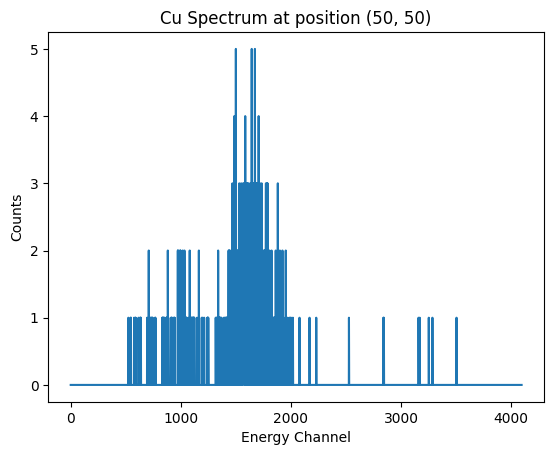

In [108]:
plt.plot(e_xy[50, 50])
plt.xlabel("Energy Channel")
plt.ylabel("Counts")
plt.title("Cu Spectrum at position (50, 50)")
plt.savefig("data/plots/cu_spectrum.svg", bbox_inches='tight')

/tmp/ipykernel_2172717/2976782103.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  original_cmap: Colormap = plt.cm.get_cmap("Greens_r")


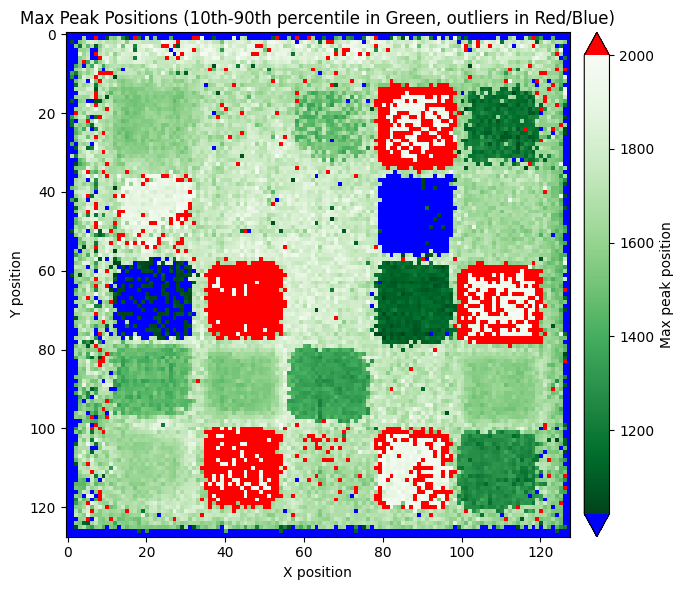

In [103]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Colormap # Import Colormap for type hinting


pads_map = np.argmax(e_xy, axis=2)

lower_bound = np.percentile(pads_map, 10)
upper_bound = np.percentile(pads_map, 90)

# Create a normalization object
norm = plt.Normalize(vmin=lower_bound, vmax=upper_bound)

# Get the 'viridis' colormap
original_cmap: Colormap = plt.cm.get_cmap("Greens_r")

# Create a copy of the colormap to modify it
custom_cmap = original_cmap.copy()

# Set colors for values outside the normalized range:
# set_under: color for values < vmin
# set_over: color for values > vmax
custom_cmap.set_under('blue')   # Example: Make values below lower_bound red
custom_cmap.set_over('red')    # Example: Make values above upper_bound blue
# You can choose any valid Matplotlib color name or an RGB tuple (e.g., (0.5, 0.5, 0.5) for gray)

plt.figure(figsize=(8, 6))

# Use the custom_cmap and the normalization
im = plt.imshow(pads_map, cmap=custom_cmap, norm=norm)

plt.title("Max Peak Positions (10th-90th percentile in Green, outliers in Red/Blue)")
plt.xlabel("X position")
plt.ylabel("Y position")

cbar = plt.colorbar(im, pad=0.02, fraction=0.046, extend='both') # Add extend='both' to show under/over colors
cbar.set_label("Max peak position")
plt.savefig("data/plots/max_peak_positions_cu.svg", format='svg', bbox_inches='tight')
plt.tight_layout()

plt.show()


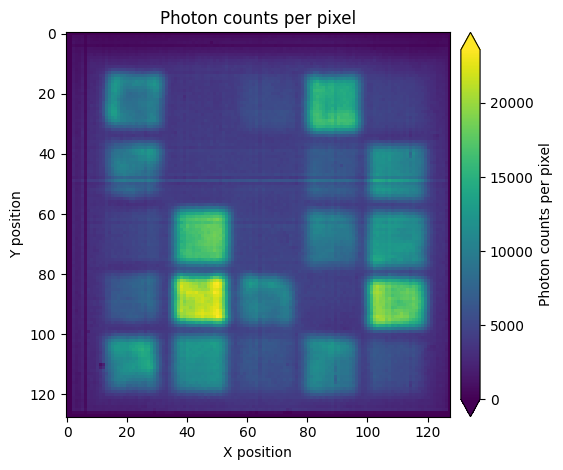

In [102]:
pads_map = np.sum(e_xy, axis=2)

im = plt.imshow(pads_map)

plt.title("Photon counts per pixel")
plt.xlabel("X position")
plt.ylabel("Y position")

cbar = plt.colorbar(im, pad=0.02, fraction=0.046, extend='both') # Add extend='both' to show under/over colors
cbar.set_label("Photon counts per pixel")
plt.savefig("data/plots/photon_count_cu.svg", format='svg', bbox_inches='tight')
plt.tight_layout()

plt.show()

In [96]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian
from skimage.transform import resize

peaks_cu = [1000, 1614]
energies_cu = [5.088, 8.046]

sobieski_e_xy_smol = resize(e_xy, np.array(e_xy.shape[:-1]) / 8 ,anti_aliasing=True)

def apply_padding(pads_e_xy, padding_size):
    smoothed_pads_e_xy = gaussian(pads_e_xy, sigma=1)
    smoothed_pads_e_xy = np.apply_along_axis(
        gaussian, axis=2, arr=smoothed_pads_e_xy, sigma=16, preserve_range=True
    )
    smoothed_pads_e_xy[:, :, :padding_size] = 0
    smoothed_pads_e_xy[:, :, -padding_size:] = 0

    return smoothed_pads_e_xy 


energy_range, spectra = DataPreprocessor.processed_spectra(apply_padding(sobieski_e_xy_smol, 196), peaks_cu, energies_cu)

/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:156: RuntimeWarning: Pixel-wise extrapolation may be slow.
  warnings.warn("Pixel-wise extrapolation may be slow.", RuntimeWarning)


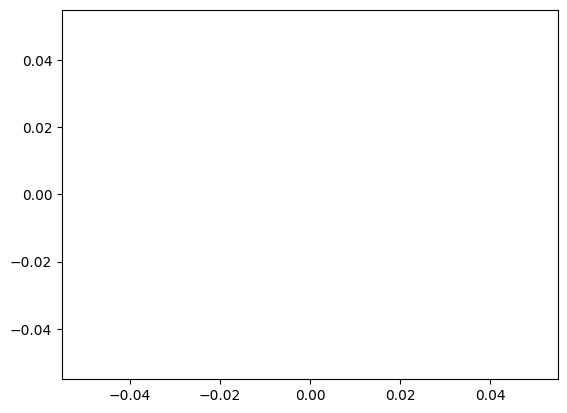

In [97]:
for i, spectrum in enumerate(spectra.flatten()):
    plt.plot(spectrum)
    if i == 10:
        break

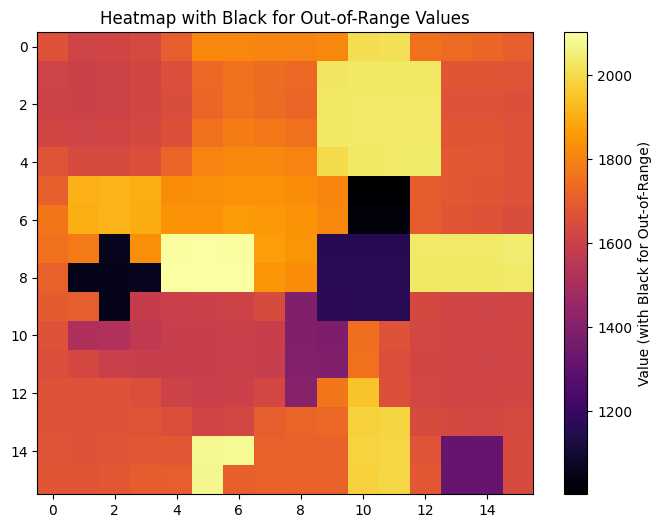

In [98]:
import matplotlib.colors as mcolors
import numpy as np

max_positions = np.argmax(spectra, axis=2)
# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(max_positions, cmap="inferno", aspect="auto")
plt.colorbar(label="Value (with Black for Out-of-Range)")
plt.title("Heatmap with Black for Out-of-Range Values")
plt.show()
